In [ ]:
!pip install findspark

In [ ]:

# Initialize Spark
import findspark
findspark.init()

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("Big Data IN CRM").getOrCreate()


In [ ]:
!unzip "/content/Year 2009-2010.csv.zip"

Archive:  /content/Year 2009-2010.csv.zip
  inflating: Year 2009-2010.csv      


In [ ]:
df = spark.read.csv("/content/Year 2009-2010.csv", header=True, inferSchema=True)

In [ ]:
df.printSchema()

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: integer (nullable = true)
 |-- Country: string (nullable = true)



In [ ]:
!unzip "/content/Year 2010-2011.csv.zip"

Archive:  /content/Year 2010-2011.csv.zip
replace Year 2010-2011.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [ ]:
df2 = spark.read.csv("/content/Year 2010-2011.csv", header=True, inferSchema=True)

In [ ]:
df2.printSchema()

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: integer (nullable = true)
 |-- Country: string (nullable = true)



In [ ]:
data = df.union(df2)

In [ ]:
data.show()

+-------+---------+--------------------+--------+--------------+-----+-----------+--------------+
|Invoice|StockCode|         Description|Quantity|   InvoiceDate|Price|Customer ID|       Country|
+-------+---------+--------------------+--------+--------------+-----+-----------+--------------+
| 489434|    85048|15CM CHRISTMAS GL...|      12|12/1/2009 7:45| 6.95|      13085|United Kingdom|
| 489434|   79323P|  PINK CHERRY LIGHTS|      12|12/1/2009 7:45| 6.75|      13085|United Kingdom|
| 489434|   79323W| WHITE CHERRY LIGHTS|      12|12/1/2009 7:45| 6.75|      13085|United Kingdom|
| 489434|    22041|"RECORD FRAME 7""...|      48|12/1/2009 7:45|  2.1|      13085|United Kingdom|
| 489434|    21232|STRAWBERRY CERAMI...|      24|12/1/2009 7:45| 1.25|      13085|United Kingdom|
| 489434|    22064|PINK DOUGHNUT TRI...|      24|12/1/2009 7:45| 1.65|      13085|United Kingdom|
| 489434|    21871| SAVE THE PLANET MUG|      24|12/1/2009 7:45| 1.25|      13085|United Kingdom|
| 489434|    21523|F

In [ ]:
data.tail(5)

[Row(Invoice='581587', StockCode='22899', Description="CHILDREN'S APRON DOLLY GIRL ", Quantity=6, InvoiceDate='12/9/2011 12:50', Price=2.1, Customer ID=12680, Country='France'),
 Row(Invoice='581587', StockCode='23254', Description='CHILDRENS CUTLERY DOLLY GIRL ', Quantity=4, InvoiceDate='12/9/2011 12:50', Price=4.15, Customer ID=12680, Country='France'),
 Row(Invoice='581587', StockCode='23255', Description='CHILDRENS CUTLERY CIRCUS PARADE', Quantity=4, InvoiceDate='12/9/2011 12:50', Price=4.15, Customer ID=12680, Country='France'),
 Row(Invoice='581587', StockCode='22138', Description='BAKING SET 9 PIECE RETROSPOT ', Quantity=3, InvoiceDate='12/9/2011 12:50', Price=4.95, Customer ID=12680, Country='France'),
 Row(Invoice='581587', StockCode='POST', Description='POSTAGE', Quantity=1, InvoiceDate='12/9/2011 12:50', Price=18.0, Customer ID=12680, Country='France')]

In [ ]:
# data cleaning
from pyspark.sql.functions import col, when, to_timestamp, expr

# 1. Remove rows with null Customer ID (important for CRM)
data_clean = data.filter(col("Customer ID").isNotNull())

# 2. Convert InvoiceDate to Timestamp
data_clean = data_clean.withColumn("InvoiceTimestamp", to_timestamp(col("InvoiceDate"), "M/d/yyyy H:mm"))

# 3. Filter out negative or zero Quantity and Price (usually cancellations or errors)
data_clean = data_clean.filter((col("Quantity") > 0) & (col("Price") > 0))

# 4. Add a TotalPrice column = Quantity * Price
data_clean = data_clean.withColumn("TotalPrice", col("Quantity") * col("Price"))

# Show cleaned sample
data_clean.show(5)

+-------+---------+--------------------+--------+--------------+-----+-----------+--------------+-------------------+------------------+
|Invoice|StockCode|         Description|Quantity|   InvoiceDate|Price|Customer ID|       Country|   InvoiceTimestamp|        TotalPrice|
+-------+---------+--------------------+--------+--------------+-----+-----------+--------------+-------------------+------------------+
| 489434|    85048|15CM CHRISTMAS GL...|      12|12/1/2009 7:45| 6.95|      13085|United Kingdom|2009-12-01 07:45:00|              83.4|
| 489434|   79323P|  PINK CHERRY LIGHTS|      12|12/1/2009 7:45| 6.75|      13085|United Kingdom|2009-12-01 07:45:00|              81.0|
| 489434|   79323W| WHITE CHERRY LIGHTS|      12|12/1/2009 7:45| 6.75|      13085|United Kingdom|2009-12-01 07:45:00|              81.0|
| 489434|    22041|"RECORD FRAME 7""...|      48|12/1/2009 7:45|  2.1|      13085|United Kingdom|2009-12-01 07:45:00|100.80000000000001|
| 489434|    21232|STRAWBERRY CERAMI...| 

In [ ]:
# EDA
num_customers = data_clean.select("Customer ID").distinct().count()
num_products = data_clean.select("StockCode").distinct().count()
num_countries = data_clean.select("Country").distinct().count()

print(f"Unique customers: {num_customers}")
print(f"Unique products: {num_products}")
print(f"Countries: {num_countries}")

Unique customers: 5878
Unique products: 4631
Countries: 41


In [ ]:
# top 10 countries by  sales revenue
top_countries = data_clean.groupBy("Country") \
    .agg(expr("sum(TotalPrice) as TotalSales")) \
    .orderBy(col("TotalSales").desc()) \
    .limit(10)

top_countries.show()

+--------------+--------------------+
|       Country|          TotalSales|
+--------------+--------------------+
|United Kingdom|1.4723147517002217E7|
|          EIRE|   621631.1099999999|
|   Netherlands|   554232.3399999987|
|       Germany|  431262.46099999984|
|        France|   355257.4700000002|
|     Australia|  169968.10999999975|
|         Spain|  109178.53000000023|
|   Switzerland|  100365.34000000014|
|        Sweden|   91549.71999999993|
|       Denmark|   69862.19000000003|
+--------------+--------------------+



In [ ]:
# sales over time monthly
from pyspark.sql.functions import date_format

data_clean = data_clean.withColumn("YearMonth", date_format(col("InvoiceTimestamp"), "yyyy-MM"))

monthly_sales = data_clean.groupBy("YearMonth") \
    .agg(expr("sum(TotalPrice) as MonthlySales")) \
    .orderBy("YearMonth")

monthly_sales.show(12)

+---------+------------------+
|YearMonth|      MonthlySales|
+---------+------------------+
|  2009-12| 686654.1599999949|
|  2010-01| 557319.0620000134|
|  2010-02|506371.06600001536|
|  2010-03| 699608.9909999889|
|  2010-04| 594609.1919999976|
|  2010-05| 599985.7900000075|
|  2010-06| 639066.5800000058|
|  2010-07| 591636.7400000065|
|  2010-08| 604242.6499999989|
|  2010-09| 831615.0009999905|
|  2010-10|1036679.9999999028|
|  2010-11|1172336.0419998672|
+---------+------------------+
only showing top 12 rows



In [ ]:
# Customer Lifetime Value (CLV) Calculation
customer_summary = data_clean.groupBy("Customer ID") \
    .agg(
        expr("sum(TotalPrice) as TotalSpent"),
        expr("count(distinct Invoice) as NumPurchases"),
        expr("avg(TotalPrice) as AvgPurchaseValue")
    ).orderBy(col("TotalSpent").desc())

customer_summary.show(10)

+-----------+------------------+------------+------------------+
|Customer ID|        TotalSpent|NumPurchases|  AvgPurchaseValue|
+-----------+------------------+------------+------------------+
|      18102|         608821.65|         145| 575.4457939508507|
|      14646| 528602.5199999999|         151|137.33502727981292|
|      14156|313946.36999999994|         156| 77.55592144268773|
|      14911| 295972.6299999998|         398|26.320376167185394|
|      17450|246973.08999999988|          51| 582.4837028301883|
|      13694|196482.81000000008|         143|128.84118688524595|
|      17511|         175603.55|          60| 91.89092098377812|
|      16446|          168472.5|           2|           56157.5|
|      16684|147142.77000000002|          55|204.93422005571034|
|      12415|144458.37000000002|          28| 156.0025593952484|
+-----------+------------------+------------+------------------+
only showing top 10 rows



In [ ]:
# Customer Segmentation (RFM Analysis)
#RFM = Recency, Frequency, Monetary

#Recency: Days since last purchase

#Frequency: Number of invoices (transactions)

#Monetary: Total spending

from pyspark.sql.functions import datediff, max as spark_max, current_date

# Calculate recency (days since last purchase)
recency_df = data_clean.groupBy("Customer ID") \
    .agg(
        spark_max("InvoiceTimestamp").alias("LastPurchaseDate"),
        expr("count(distinct Invoice)").alias("Frequency"),
        expr("sum(TotalPrice)").alias("Monetary")
    )

# Add Recency column (days since last purchase)
recency_df = recency_df.withColumn("Recency", datediff(current_date(), col("LastPurchaseDate")))

recency_df.select("Customer ID", "Recency", "Frequency", "Monetary").show(10)

+-----------+-------+---------+------------------+
|Customer ID|Recency|Frequency|          Monetary|
+-----------+-------+---------+------------------+
|      15447|   5260|        5|            492.88|
|      18051|   5564|        7|2282.2799999999997|
|      17389|   4930|       61|          57224.68|
|      14832|   5560|        1|            322.69|
|      15727|   4946|       15|           9445.51|
|      17753|   5394|        4|390.55999999999995|
|      17679|   4982|        7|3577.6100000000006|
|      16861|   4989|        5| 946.5899999999999|
|      13285|   4953|        6|3364.5899999999997|
|      16503|   5036|       11|           3614.34|
+-----------+-------+---------+------------------+
only showing top 10 rows



In [ ]:
# Assign RFM Score (1-5 scale)
from pyspark.sql.window import Window
from pyspark.sql.functions import ntile

# Create window specs for ranking
window_recency = Window.orderBy("Recency")
window_frequency = Window.orderBy(col("Frequency").desc())
window_monetary = Window.orderBy(col("Monetary").desc())

# Assign scores (1=lowest, 5=highest for Frequency and Monetary; reverse for Recency)
rfm_scored = recency_df \
    .withColumn("R_Score", ntile(5).over(window_recency)) \
    .withColumn("F_Score", ntile(5).over(window_frequency)) \
    .withColumn("M_Score", ntile(5).over(window_monetary))

# Calculate RFM Score by combining R, F, M scores
rfm_scored = rfm_scored.withColumn("RFM_Score", col("R_Score") + col("F_Score") + col("M_Score"))

rfm_scored.select("Customer ID", "Recency", "Frequency", "Monetary", "R_Score", "F_Score", "M_Score", "RFM_Score") \
    .orderBy(col("RFM_Score").desc()) \
    .show(10)



+-----------+-------+---------+------------------+-------+-------+-------+---------+
|Customer ID|Recency|Frequency|          Monetary|R_Score|F_Score|M_Score|RFM_Score|
+-----------+-------+---------+------------------+-------+-------+-------+---------+
|      15391|   5514|        1|            289.87|      5|      5|      5|       15|
|      15772|   5348|        1|280.88000000000005|      5|      5|      5|       15|
|      13796|   5429|        1|             289.7|      5|      5|      5|       15|
|      14433|   5395|        1|289.59999999999997|      5|      5|      5|       15|
|      14402|   5582|        1|             285.6|      5|      5|      5|       15|
|      12487|   5660|        1|285.29999999999995|      5|      5|      5|       15|
|      15338|   5607|        1| 283.4299999999999|      5|      5|      5|       15|
|      13511|   5606|        1|            282.76|      5|      5|      5|       15|
|      12771|   5415|        1|             282.3|      5|      5

In [ ]:
# customer segments based on rfm score
from pyspark.sql.functions import when

rfm_final = rfm_scored.withColumn(
    "Segment",
    when(col("RFM_Score") >= 13, "Champions")
    .when((col("RFM_Score") >= 10) & (col("RFM_Score") < 13), "Loyal Customers")
    .when((col("RFM_Score") >= 7) & (col("RFM_Score") < 10), "Potential Loyalists")
    .otherwise("Needs Attention")
)

rfm_final.groupBy("Segment").count().show()


+-------------------+-----+
|            Segment|count|
+-------------------+-----+
|    Needs Attention| 1755|
|Potential Loyalists| 1419|
|    Loyal Customers| 1394|
|          Champions| 1310|
+-------------------+-----+



In [ ]:
top_countries_pd = top_countries.toPandas()

<ipython-input-49-aff65aca0f7a>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries_pd, x='Country', y='TotalSales', palette='viridis')


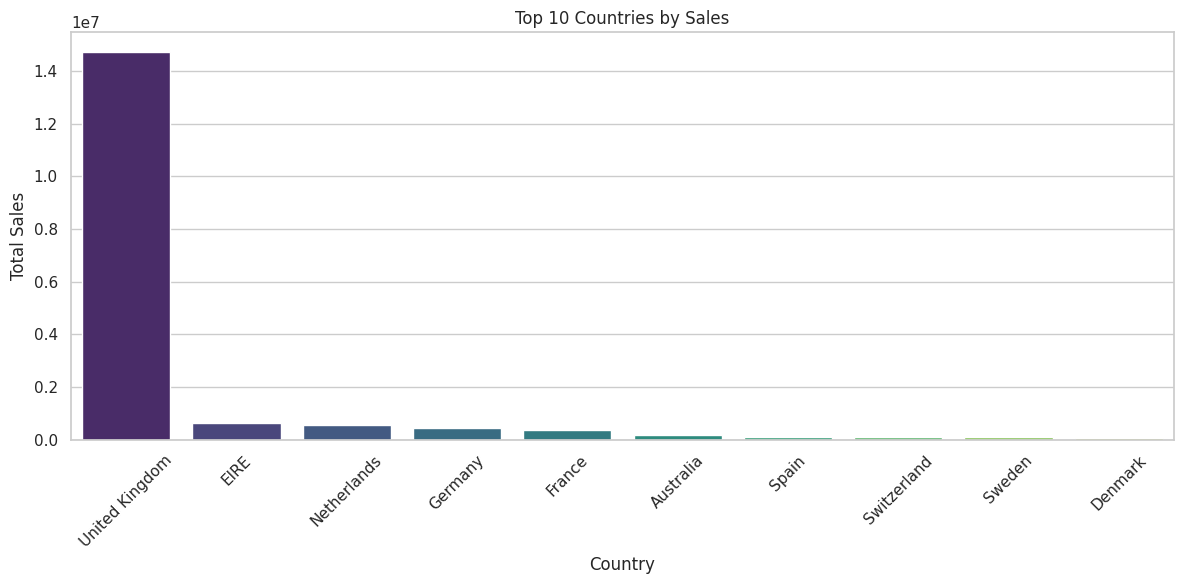

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Plot Top 10 Countries by Sales
plt.figure(figsize=(12,6))
sns.barplot(data=top_countries_pd, x='Country', y='TotalSales', palette='viridis')
plt.title("Top 10 Countries by Sales")
plt.xticks(rotation=45)
plt.ylabel("Total Sales")
plt.xlabel("Country")
plt.tight_layout()
plt.show()


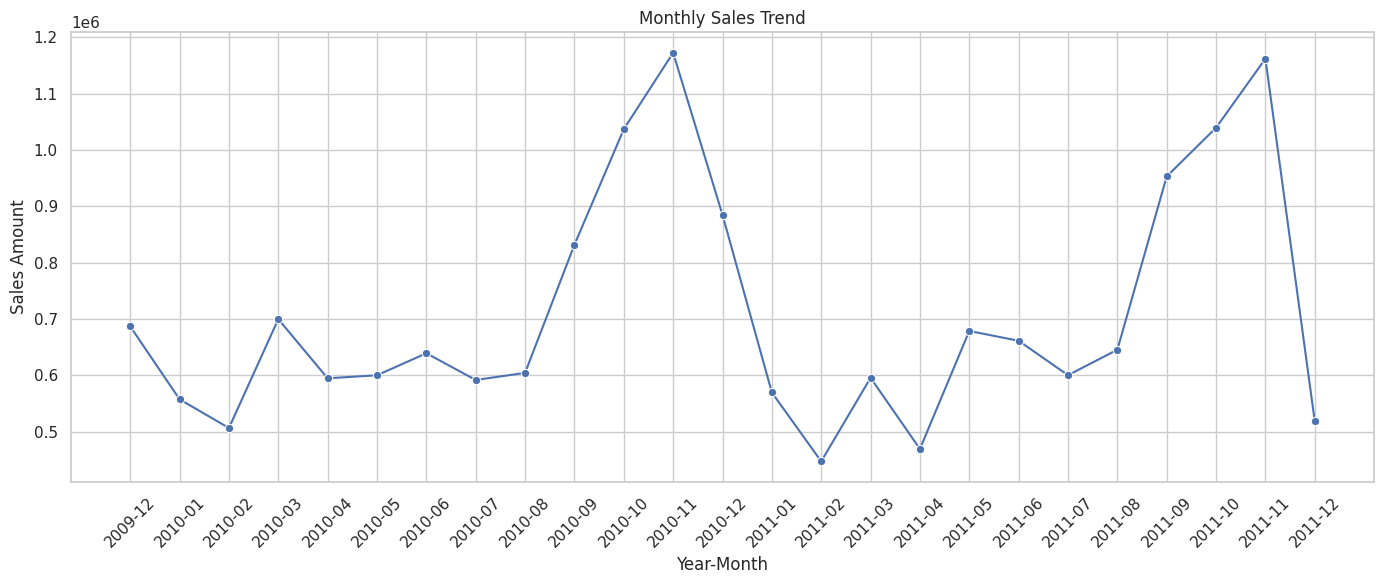

In [ ]:
# Convert monthly sales to Pandas
monthly_sales_pd = monthly_sales.toPandas()

plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_sales_pd, x='YearMonth', y='MonthlySales', marker='o')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.ylabel('Sales Amount')
plt.xlabel('Year-Month')
plt.tight_layout()
plt.show()


<ipython-input-51-e907594beee0>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_count, x='Segment', y='count', palette='Set2')


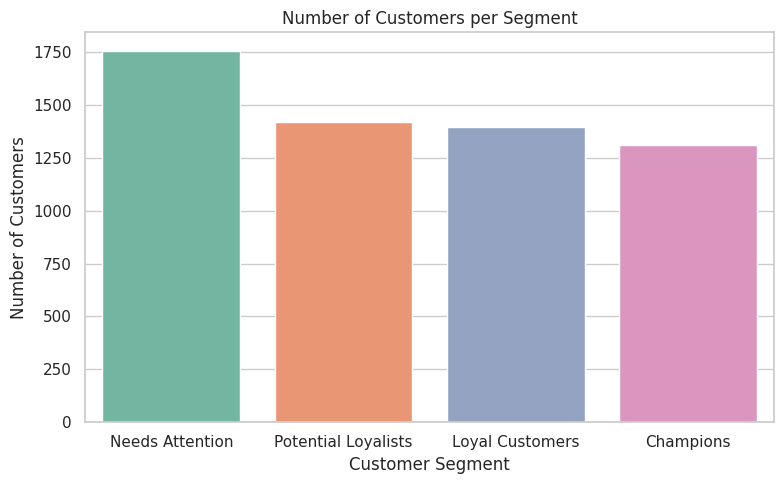

In [ ]:
# Count of customers in each segment
segment_count = rfm_final.groupBy("Segment").count().toPandas()

plt.figure(figsize=(8,5))
sns.barplot(data=segment_count, x='Segment', y='count', palette='Set2')
plt.title('Number of Customers per Segment')
plt.ylabel('Number of Customers')
plt.xlabel('Customer Segment')
plt.tight_layout()
plt.show()


<ipython-input-52-56d81ed1163b>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='R_Score', data=rfm_pd, palette='Blues')
<ipython-input-52-56d81ed1163b>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='F_Score', data=rfm_pd, palette='Greens')
<ipython-input-52-56d81ed1163b>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='M_Score', data=rfm_pd, palette='Reds')


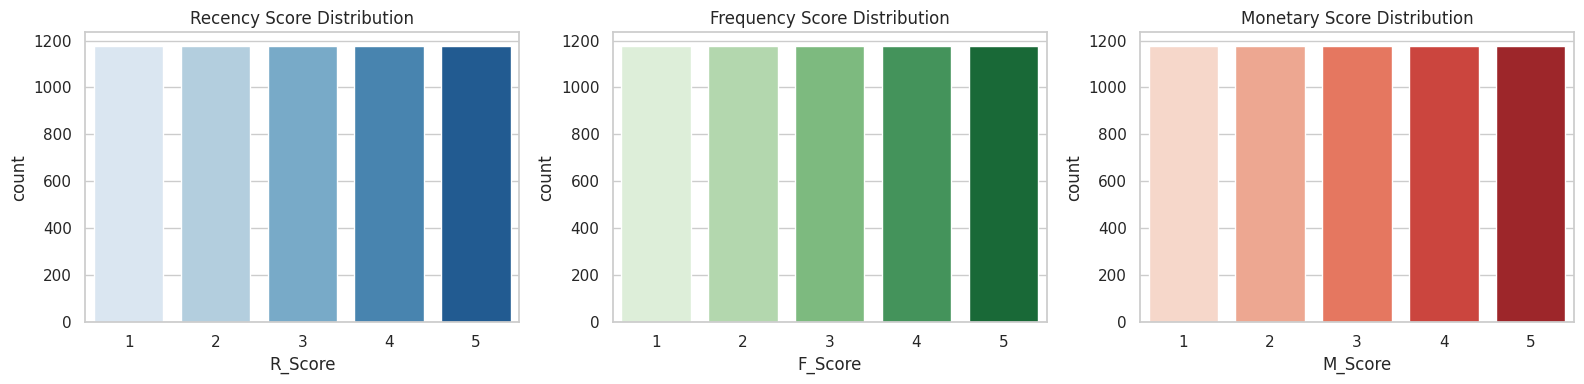

In [ ]:
rfm_pd = rfm_final.select("R_Score", "F_Score", "M_Score").toPandas()

plt.figure(figsize=(16,4))

plt.subplot(1,3,1)
sns.countplot(x='R_Score', data=rfm_pd, palette='Blues')
plt.title('Recency Score Distribution')

plt.subplot(1,3,2)
sns.countplot(x='F_Score', data=rfm_pd, palette='Greens')
plt.title('Frequency Score Distribution')

plt.subplot(1,3,3)
sns.countplot(x='M_Score', data=rfm_pd, palette='Reds')
plt.title('Monetary Score Distribution')

plt.tight_layout()
plt.show()


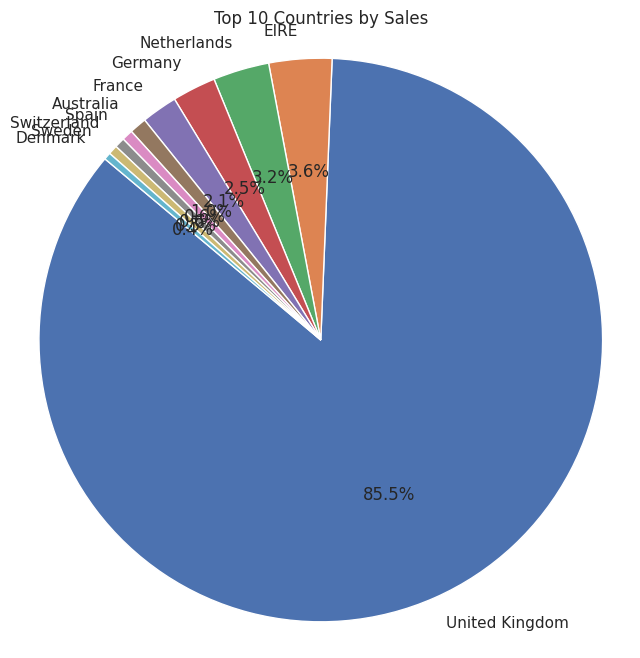

In [ ]:
plt.figure(figsize=(8,8))
plt.pie(top_countries_pd['TotalSales'], labels=top_countries_pd['Country'], autopct='%1.1f%%', startangle=140)
plt.title("Top 10 Countries by Sales")
plt.axis('equal')
plt.show()


<ipython-input-56-28c2097cd233>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries_pd, x='Country', y='TotalSales', palette='magma')


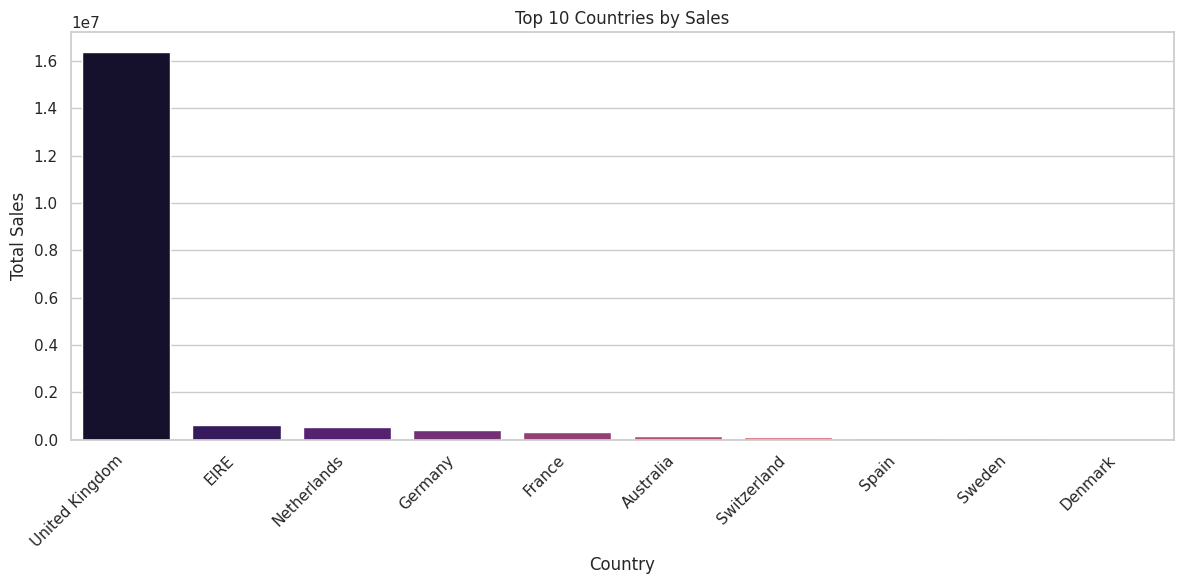

In [ ]:
from pyspark.sql.functions import col, sum as spark_sum
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Aggregate total sales by country (PySpark)
country_sales = data.groupBy("Country").agg(
    spark_sum(col("Quantity") * col("Price")).alias("TotalSales")
)

# Step 2: Get top 10 countries by sales
top_countries = country_sales.orderBy(col("TotalSales").desc()).limit(10)

# Step 3: Collect to driver (small dataset, so okay)
top_countries_pd = top_countries.toPandas()

# Step 4: Plot using seaborn barplot
plt.figure(figsize=(12,6))
sns.barplot(data=top_countries_pd, x='Country', y='TotalSales', palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()
